In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (12, 6)

In [3]:
DATA_PATH = Path("../data/silver/browser_ram_aligned.parquet")

df = pd.read_parquet(DATA_PATH)

print(f"Shape: {df.shape}")
df.head()

Shape: (25917, 9)


,timestamp,url,title,domain,visit_count,total_mb,used_mb,available_mb,usage_percent
0,2026-05-10 07:57:45.724093+00:00,https://www.instagram.com/p/DWbzENEkoXZ/?chain...,Motivation | Masculinity | Wisdom | 🇯🇵この速度に達する...,www.instagram.com,1,8192,3139.88,5052.12,38.33
1,2026-05-10 07:58:01.129075+00:00,https://www.instagram.com/explore/,Instagram,www.instagram.com,395,8192,3348.61,4843.39,40.88
2,2026-05-10 07:58:23.218971+00:00,https://www.instagram.com/explore/,Instagram,www.instagram.com,395,8192,2937.28,5254.72,35.86
3,2026-05-10 07:58:24.793832+00:00,https://www.instagram.com/explore/search/,Instagram,www.instagram.com,57,8192,3035.53,5156.47,37.05
4,2026-05-10 07:58:39.156316+00:00,https://www.instagram.com/explore/search/keywo...,#fedorahats • Instagram,www.instagram.com,1,8192,3296.28,4895.72,40.24


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25917 entries, 0 to 25916
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   timestamp      25917 non-null  datetime64[us, UTC]
 1   url            25917 non-null  str                
 2   title          25917 non-null  str                
 3   domain         25916 non-null  str                
 4   visit_count    25917 non-null  int64              
 5   total_mb       25917 non-null  int64              
 6   used_mb        25917 non-null  float64            
 7   available_mb   25917 non-null  float64            
 8   usage_percent  25917 non-null  float64            
dtypes: datetime64[us, UTC](1), float64(3), int64(2), str(3)
memory usage: 14.0 MB


In [5]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    utc=True,
)

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.day_name()
df["date"] = df["timestamp"].dt.date
df["day_of_week_num"] = df["timestamp"].dt.dayofweek

# Temporal Distribution

In [6]:
# browsing activity by hour of the day
hourly_activity = (
    df.groupby("hour")
    .size()
    .reindex(range(24), fill_value=0)
)

hourly_activity

hour
0      192
1      690
2     1902
3     1131
4     1355
5     1341
6     1106
7     1316
8     1811
9     1598
10    1940
11    2286
12    1321
13    1693
14    1360
15    1422
16    1503
17    1245
18     537
19     108
20       0
21       5
22      12
23      43
dtype: int64

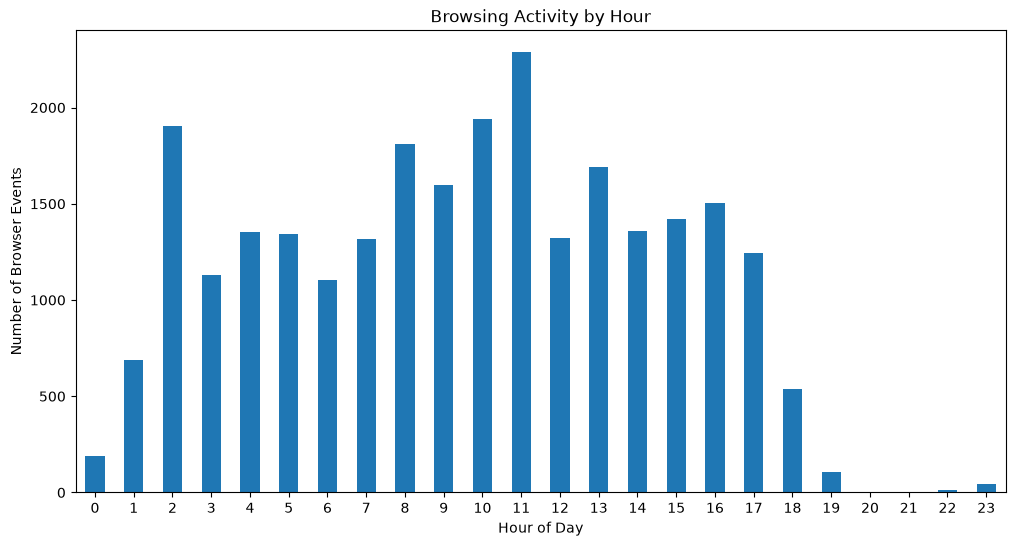

In [7]:
plt.figure(figsize=(12, 6))

hourly_activity.plot(kind="bar")

plt.title("Browsing Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Browser Events")
plt.xticks(rotation=0)

plt.show()

In [8]:
# browsing activity by day of the week
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

daily_week_activity = (
    df.groupby("day_of_week")
    .size()
    .reindex(day_order)
)

daily_week_activity

day_of_week
Monday       3774
Tuesday      4014
Wednesday    3997
Thursday     4102
Friday       2989
Saturday     3089
Sunday       3952
dtype: int64

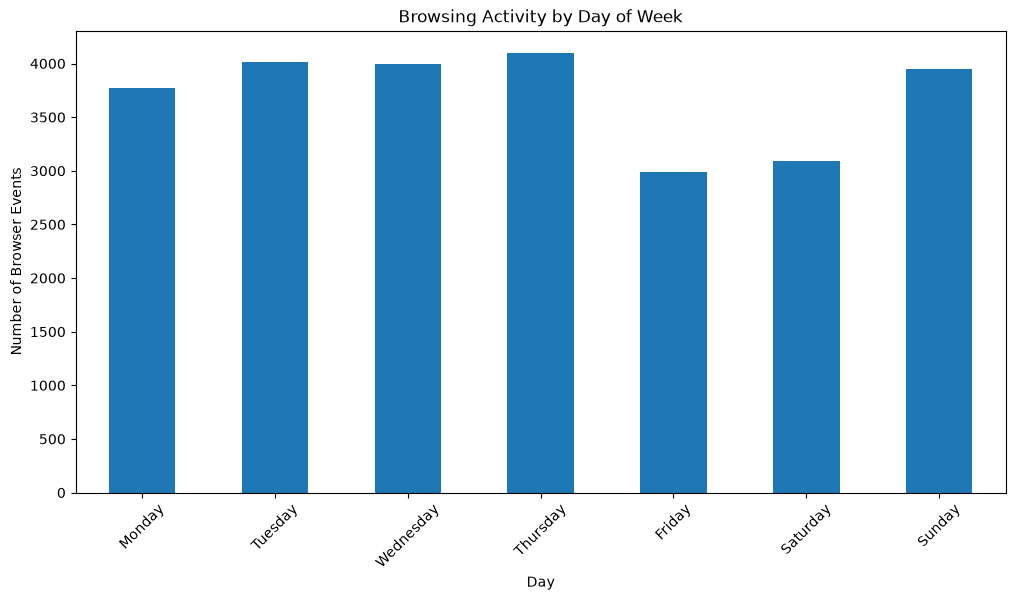

In [9]:
plt.figure(figsize=(12, 6))

daily_week_activity.plot(kind="bar")

plt.title("Browsing Activity by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Browser Events")
plt.xticks(rotation=45)

plt.show()

In [10]:
# daily browsing activity
daily_activity = (
    df.groupby("date")
    .size()
)

daily_activity.head()

date
2026-05-10    435
2026-05-11    423
2026-05-12     41
2026-05-13    151
2026-05-14    129
dtype: int64

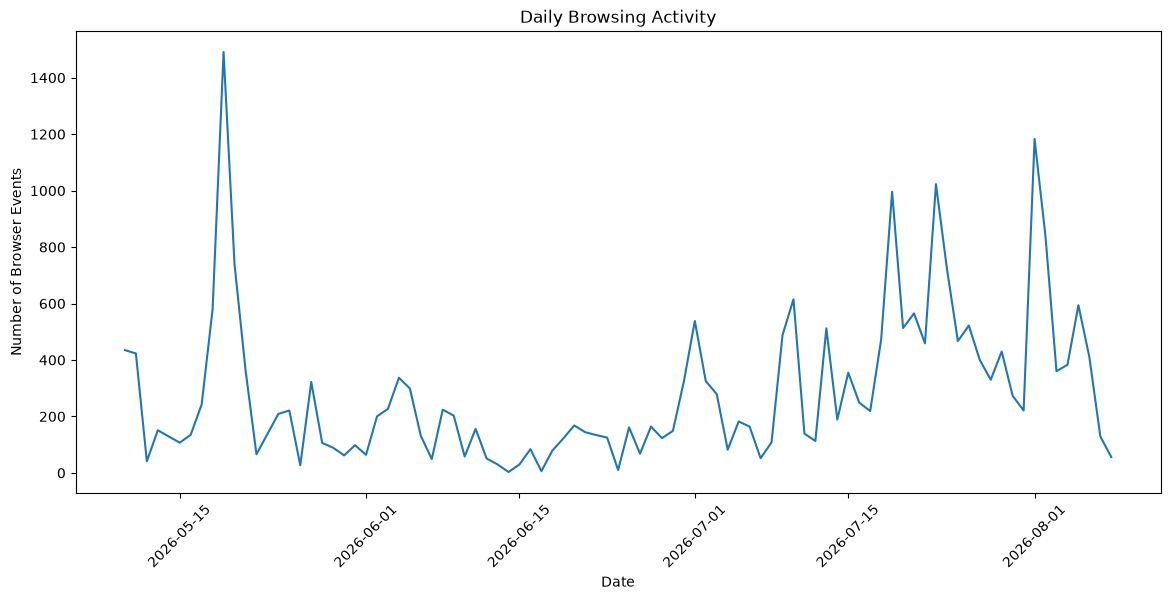

In [11]:
plt.figure(figsize=(14, 6))

daily_activity.plot()

plt.title("Daily Browsing Activity")
plt.xlabel("Date")
plt.ylabel("Number of Browser Events")

plt.xticks(rotation=45)

plt.show()

# Browser Behaviour

In [12]:
# most visited websites
domain_counts = (
    df["domain"]
    .dropna()
    .value_counts()
)

domain_counts.head(20)

domain
www.google.com                            11308
www.instagram.com                          3292
colab.research.google.com                  2384
m.youtube.com                               861
github.com                                  590
accounts.google.com                         535
www.youtube.com                             398
docs.google.com                             299
www.linkedin.com                            271
drive.google.com                            242
www.guvi.in                                 195
careerzenith.ai                             189
mail.google.com                             153
learn.microsoft.com                         146
chatgpt.com                                 139
www.canva.com                               134
propelld.com                                134
dbc-769439ff-d9f3.cloud.databricks.com      133
www.flipkart.com                             94
www.databricks.com                           92
Name: count, dtype: int64

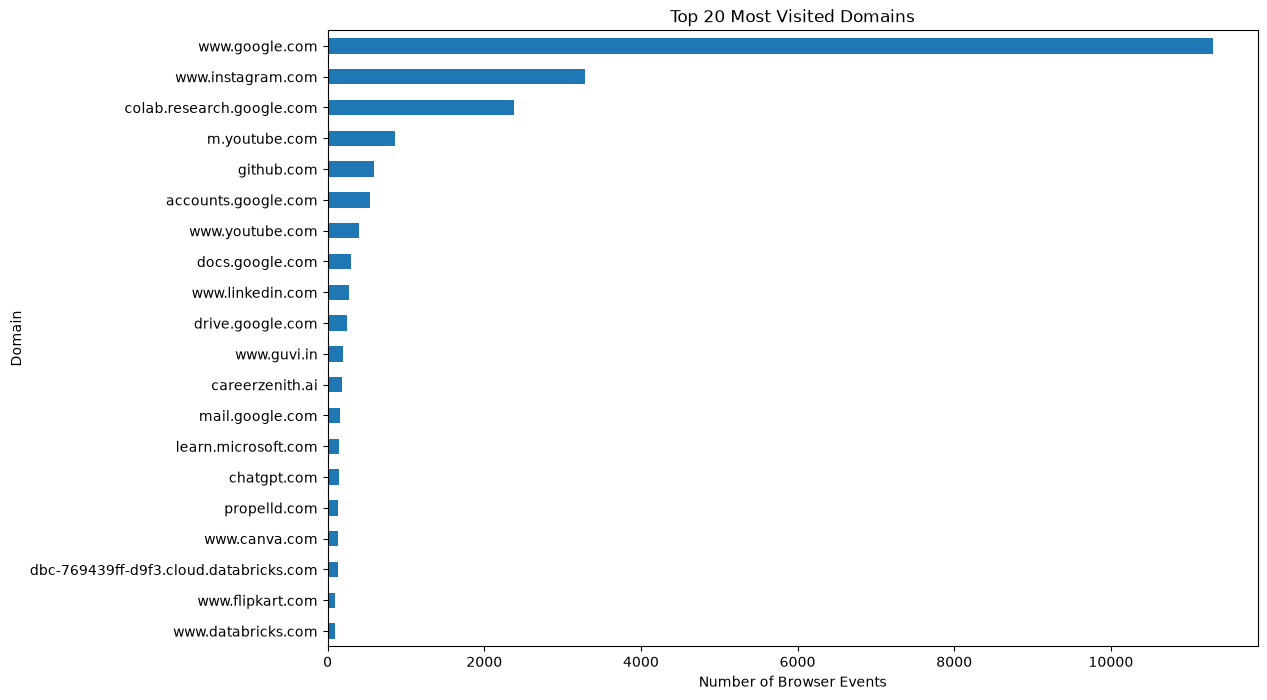

In [13]:
top_domains = domain_counts.head(20).sort_values()

plt.figure(figsize=(12, 8))

top_domains.plot(kind="barh")

plt.title("Top 20 Most Visited Domains")
plt.xlabel("Number of Browser Events")
plt.ylabel("Domain")

plt.show()

In [14]:
# visit frequency distribution

visit_frequency = (
    df.groupby("domain")
    .agg(
        visits=("domain", "size"),
        unique_urls=("url", "nunique"),
        total_visit_count=("visit_count", "sum"),
    )
    .sort_values("visits", ascending=False)
)

visit_frequency.head(20)

,visits,unique_urls,total_visit_count
domain,,,
www.google.com,11308,7163,26898
www.instagram.com,3292,1123,320919
colab.research.google.com,2384,350,42024
m.youtube.com,861,479,29293
github.com,590,251,6391
accounts.google.com,535,504,753
www.youtube.com,398,196,8452
docs.google.com,299,102,3478
www.linkedin.com,271,128,5261


In [16]:
# unique URL distribution

unique_domains = df["domain"].nunique()
print(f"Unique domains: {unique_domains:,}")

Unique domains: 664


In [18]:
unique_urls = df["url"].nunique()
print(f"Unique URLs: {unique_urls:,}")

Unique URLs: 13,267


In [19]:
unique_titles = df["title"].nunique()
print(f"Unique page titles: {unique_titles:,}")

Unique page titles: 4,377


In [20]:
# Repeated Visits

url_frequency = (
    df["url"]
    .value_counts()
)

url_frequency.head(20)

url
https://www.instagram.com/explore/                                                                            425
https://www.instagram.com/direct/inbox/                                                                       269
https://www.instagram.com/                                                                                    265
https://m.youtube.com/                                                                                        166
https://www.instagram.com/direct/t/1683823392972925/                                                           97
https://www.youtube.com/                                                                                       89
https://drive.google.com/drive/u/0/my-drive                                                                    74
https://www.linkedin.com/in/abish3k-murugan/                                                                   66
https://www.instagram.com/explore/search/                                           

In [21]:
single_visit_urls = (url_frequency == 1).sum()

repeated_visit_urls = (url_frequency > 1).sum()

print(f"URLs visited once: {single_visit_urls:,}")
print(f"URLs visited multiple times: {repeated_visit_urls:,}")

URLs visited once: 9,017
URLs visited multiple times: 4,250


In [22]:
total_unique_urls = len(url_frequency)

repeated_percentage = (
    repeated_visit_urls / total_unique_urls * 100
)

print(
    f"Repeated URL percentage: "
    f"{repeated_percentage:.2f}%"
)

Repeated URL percentage: 32.03%


# Ram Relationship

In [24]:
# Ram usage analysis

df["usage_percent"].describe()

count    25917.000000
mean        42.012783
std          6.739810
min         20.550000
25%         37.120000
50%         41.660000
75%         46.830000
max         65.220000
Name: usage_percent, dtype: float64

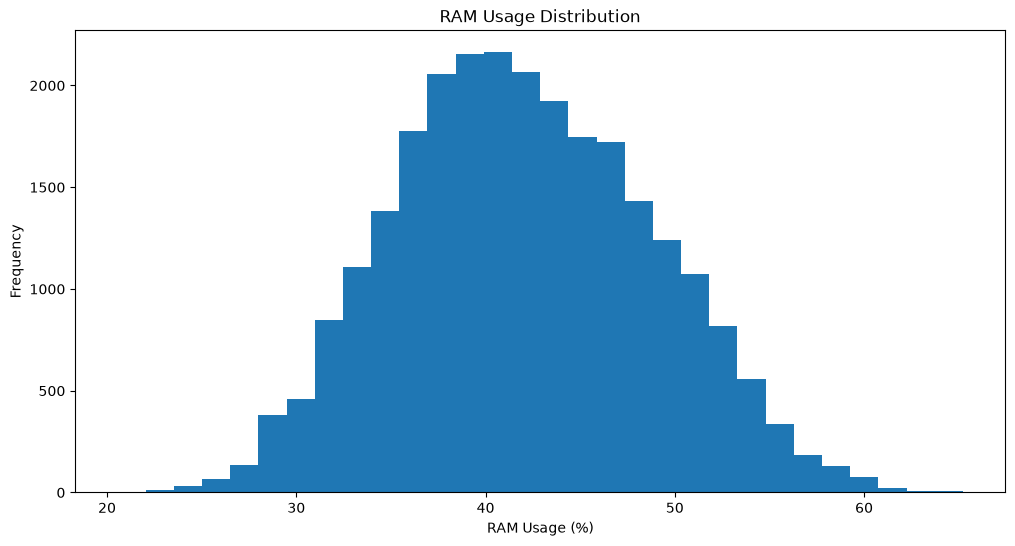

In [25]:
plt.figure(figsize=(12, 6))

df["usage_percent"].plot(
    kind="hist",
    bins=30,
)

plt.title("RAM Usage Distribution")
plt.xlabel("RAM Usage (%)")
plt.ylabel("Frequency")

plt.show()

/tmp/ipykernel_7422/1494793786.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


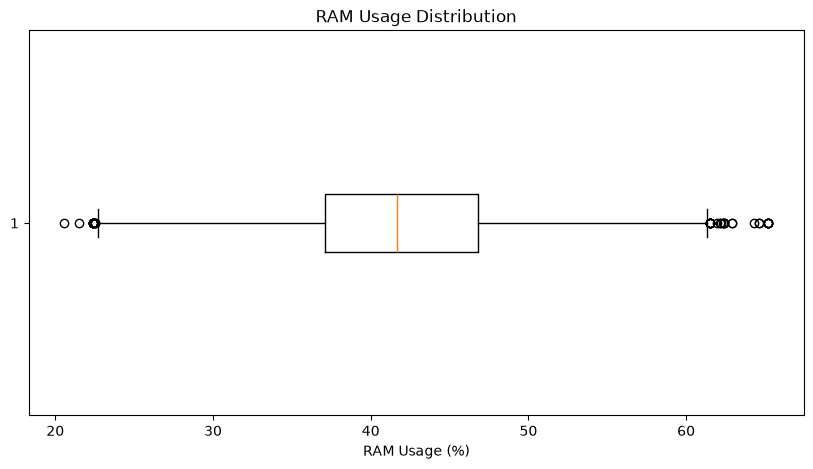

In [26]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    df["usage_percent"].dropna(),
    vert=False,
)

plt.title("RAM Usage Distribution")
plt.xlabel("RAM Usage (%)")

plt.show()

In [27]:
# ram usage during browsing activity 
ram_during_browsing = df[
    [
        "timestamp",
        "domain",
        "used_mb",
        "available_mb",
        "usage_percent",
    ]
]

ram_during_browsing.describe()

,used_mb,available_mb,usage_percent
count,25917.000000,25917.000000,25917.000000
mean,3441.686815,4750.313185,42.012783
std,552.128312,552.128312,6.739810
min,1683.700000,2849.400000,20.550000
25%,3041.060000,4356.010000,37.120000
50%,3412.620000,4779.380000,41.660000
75%,3835.990000,5150.940000,46.830000
max,5342.600000,6508.300000,65.220000


In [28]:
ram_by_hour = (
    df.groupby("hour")["usage_percent"]
    .agg(
        mean="mean",
        median="median",
        min="min",
        max="max",
    )
)

ram_by_hour

,mean,median,min,max
hour,,,,
0,40.772083,41.445,26.68,49.81
1,40.186826,40.160,28.06,52.63
2,37.659111,37.675,24.81,53.07
3,36.774633,37.020,23.36,54.43
4,36.210524,36.270,20.55,49.52
5,35.766465,35.710,22.42,51.57
6,36.626230,36.470,23.82,48.76
7,36.963533,37.010,23.85,49.13
8,37.575146,37.550,23.68,50.38


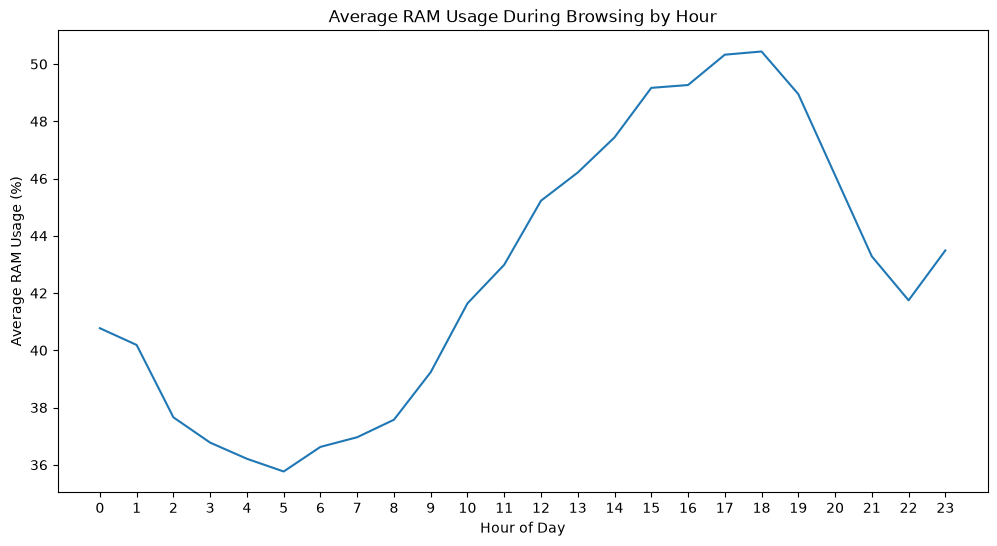

In [29]:
plt.figure(figsize=(12, 6))

ram_by_hour["mean"].plot()

plt.title("Average RAM Usage During Browsing by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average RAM Usage (%)")

plt.xticks(range(24))

plt.show()

In [30]:
# browsing activity vs ram usage
hourly_behavior = (
    df.groupby("hour")
    .agg(
        browser_events=("timestamp", "size"),
        avg_ram_usage=("usage_percent", "mean"),
        max_ram_usage=("usage_percent", "max"),
    )
)

hourly_behavior

,browser_events,avg_ram_usage,max_ram_usage
hour,,,
0,192,40.772083,49.81
1,690,40.186826,52.63
2,1902,37.659111,53.07
3,1131,36.774633,54.43
4,1355,36.210524,49.52
5,1341,35.766465,51.57
6,1106,36.626230,48.76
7,1316,36.963533,49.13
8,1811,37.575146,50.38


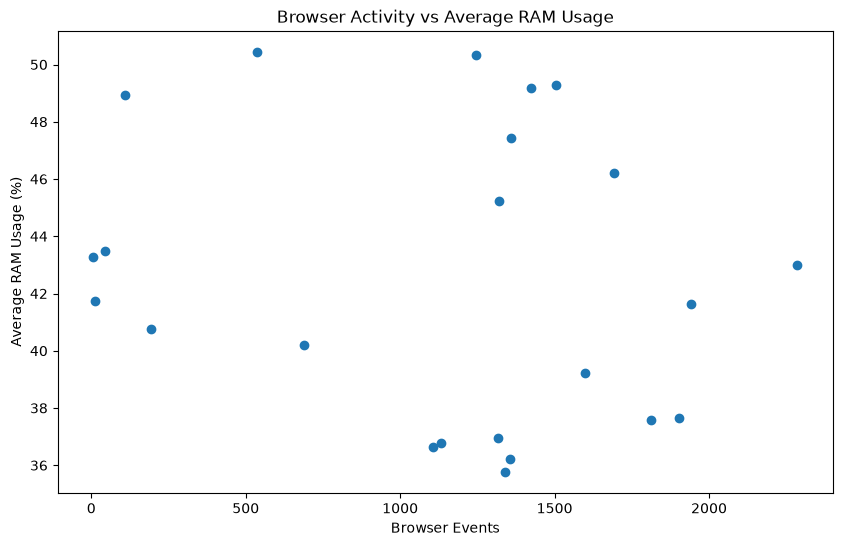

In [31]:
plt.figure(figsize=(10, 6))

plt.scatter(
    hourly_behavior["browser_events"],
    hourly_behavior["avg_ram_usage"],
)

plt.xlabel("Browser Events")
plt.ylabel("Average RAM Usage (%)")
plt.title("Browser Activity vs Average RAM Usage")

plt.show()

In [32]:
correlation = hourly_behavior[
    [
        "browser_events",
        "avg_ram_usage",
    ]
].corr()

correlation

,browser_events,avg_ram_usage
browser_events,1.000000,-0.174574
avg_ram_usage,-0.174574,1.000000


# Data Quality

In [ ]:
# duplicate rows
duplicate_rows = df.duplicated().sum()

print(f"Exact duplicate rows: {duplicate_rows:,}")

Exact duplicate rows: 52


In [34]:
duplicate_events = df.duplicated(
    subset=["timestamp", "url"]
).sum()

print(
    f"Duplicate timestamp + URL events: "
    f"{duplicate_events:,}"
)

Duplicate timestamp + URL events: 52


In [35]:
# timestamp gaps

df = df.sort_values("timestamp").reset_index(drop=True)

In [36]:
df["time_gap_seconds"] = (
    df["timestamp"]
    .diff()
    .dt.total_seconds()
)

In [37]:
df["time_gap_seconds"].describe()

count     25916.000000
mean        300.042187
std        2898.246340
min           0.000000
25%           0.588624
50%           3.810855
75%          14.787631
max      216546.091834
Name: time_gap_seconds, dtype: float64

In [38]:
largest_gaps = (
    df[
        [
            "timestamp",
            "domain",
            "time_gap_seconds",
        ]
    ]
    .sort_values(
        "time_gap_seconds",
        ascending=False,
    )
    .head(20)
)

largest_gaps

,timestamp,domain,time_gap_seconds
4905,2026-05-24 14:35:09.395223+00:00,www.google.com,216546.091834
8071,2026-06-15 04:36:53.724314+00:00,www.google.com,97453.493090
11368,2026-07-06 13:22:38.201125+00:00,www.google.com,74979.281155
1050,2026-05-14 06:37:11.346421+00:00,www.google.com,72031.905212
1286,2026-05-16 10:29:16.039143+00:00,www.google.com,71328.941893
8963,2026-06-24 04:22:21.227868+00:00,www.google.com,66781.153349
7297,2026-06-07 05:58:38.457230+00:00,www.google.com,63064.418410
7987,2026-06-12 08:25:40.405614+00:00,www.google.com,57125.133987
1663,2026-05-18 07:20:10.507648+00:00,www.shopsy.in,54233.218195
8191,2026-06-18 04:18:54.885325+00:00,www.google.com,52623.621336


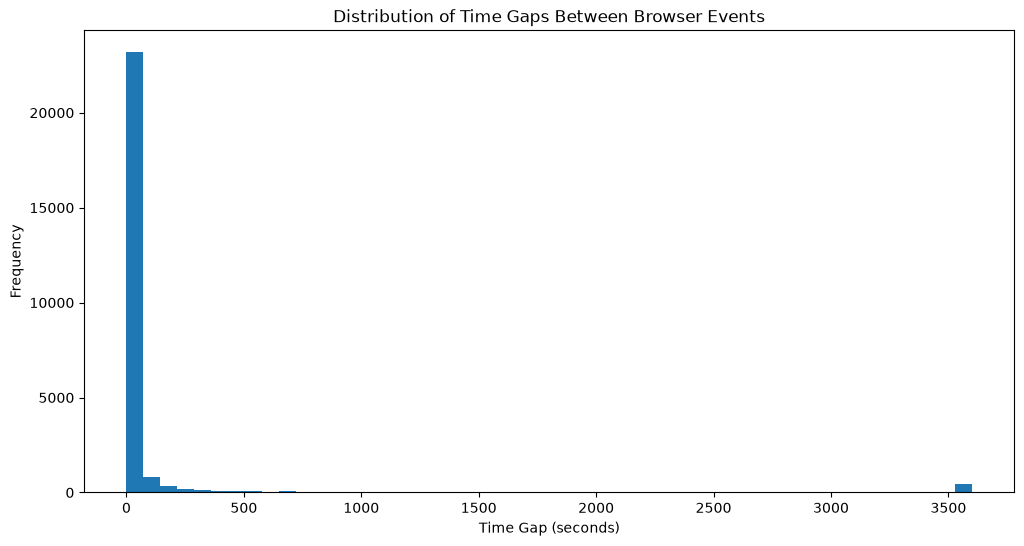

In [39]:
plt.figure(figsize=(12, 6))

df["time_gap_seconds"].dropna().clip(
    upper=3600
).plot(
    kind="hist",
    bins=50,
)

plt.title("Distribution of Time Gaps Between Browser Events")
plt.xlabel("Time Gap (seconds)")
plt.ylabel("Frequency")

plt.show()

In [40]:
# Suspicious values
invalid_ram = df[
    (df["usage_percent"] < 0)
    | (df["usage_percent"] > 100)
]

print(
    f"Invalid RAM usage records: "
    f"{len(invalid_ram):,}"
)

Invalid RAM usage records: 0


In [41]:
df["memory_difference_mb"] = (
    df["total_mb"]
    - df["used_mb"]
    - df["available_mb"]
)

df["memory_difference_mb"].describe()

count    2.591700e+04
mean    -7.930926e-15
std      4.316675e-13
min     -9.094947e-13
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.094947e-13
Name: memory_difference_mb, dtype: float64

In [42]:
suspicious_memory = df[
    df["memory_difference_mb"].abs() > 100
]

print(
    f"Suspicious memory records: "
    f"{len(suspicious_memory):,}"
)

Suspicious memory records: 0


In [43]:
print(
    "Missing URLs:",
    df["url"].isna().sum(),
)

Missing URLs: 0


In [44]:
empty_urls = (
    df["url"]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print(f"Empty URLs: {empty_urls:,}")

Empty URLs: 0


In [45]:
print(
    "Missing titles:",
    df["title"].isna().sum(),
)

Missing titles: 0


In [46]:
# Outliers in RAM usage
q1 = df["usage_percent"].quantile(0.25)
q3 = df["usage_percent"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

ram_outliers = df[
    (df["usage_percent"] < lower_bound)
    | (df["usage_percent"] > upper_bound)
]

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Outliers: {len(ram_outliers):,}")

Q1: 37.12
Q3: 46.83
IQR: 9.71
Lower bound: 22.55
Upper bound: 61.39
Outliers: 38


/tmp/ipykernel_7422/2259918742.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


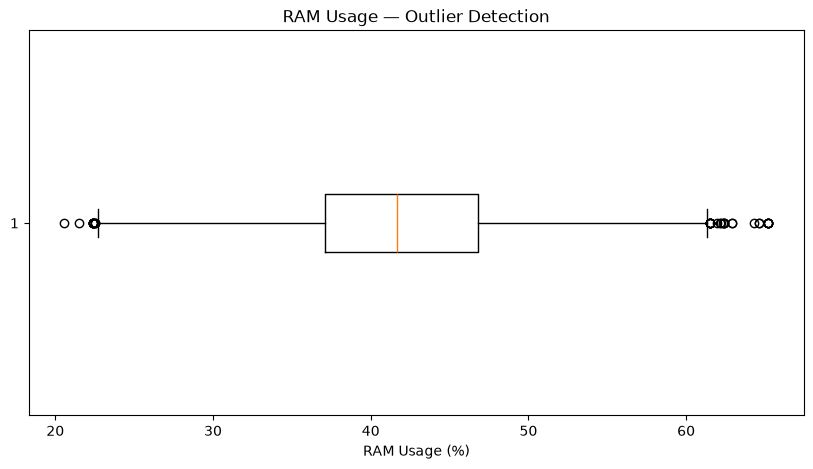

In [47]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    df["usage_percent"].dropna(),
    vert=False,
)

plt.title("RAM Usage — Outlier Detection")
plt.xlabel("RAM Usage (%)")

plt.show()

In [48]:
eda_summary = {
    "total_records": len(df),
    "unique_domains": df["domain"].nunique(),
    "unique_urls": df["url"].nunique(),
    "duplicate_rows": int(df.duplicated().sum()),
    "duplicate_events": int(
        df.duplicated(
            subset=["timestamp", "url"]
        ).sum()
    ),
    "missing_domains": int(df["domain"].isna().sum()),
    "missing_urls": int(df["url"].isna().sum()),
    "mean_ram_usage": float(
        df["usage_percent"].mean()
    ),
    "median_ram_usage": float(
        df["usage_percent"].median()
    ),
    "max_ram_usage": float(
        df["usage_percent"].max()
    ),
    "ram_outliers": len(ram_outliers),
}

pd.Series(eda_summary)

total_records       25917.000000
unique_domains        664.000000
unique_urls         13267.000000
duplicate_rows         11.000000
duplicate_events       52.000000
missing_domains         1.000000
missing_urls            0.000000
mean_ram_usage         42.012783
median_ram_usage       41.660000
max_ram_usage          65.220000
ram_outliers           38.000000
dtype: float64